In [10]:
import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
import time
import os
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import gzip

# --- HELPER FUNCTIONS ---
def build_tree_features(df):
    x = df.copy().sort_values(by="timestamp")
    for lag in [1, 2, 24]:
        x[f"lag_{lag}"] = x["request_count"].shift(lag)
    x["hour_sin"] = np.sin(2 * np.pi * x.index.hour / 24)
    x["hour_cos"] = np.cos(2 * np.pi * x.index.hour / 24)
    x["target"] = x["request_count"].shift(-1)
    return x.dropna()

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTMModel, self).__init__()
        self.hidden_dim, self.num_layers = hidden_dim, num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        return self.fc(out[:, -1, :])



def train_test_split(raw_data,target, features, test_size=0.2, random_state=42):
    X = raw_data[features]
    y = raw_data[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    print(f"Training set size: {X_train.shape[0]} samples")
    print(f"Test set size: {X_test.shape[0]} samples")

    return X_train, X_test, y_train, y_test

# --- 1. ROBUST PARSING & AGGREGATION ---
LOG_PATTERN = re.compile(r'(\S+) - - \[(.*?)\] "(.*?)" (\d{3}) (\S+)')

def parse_line(line):
    m = LOG_PATTERN.match(line.strip())
    if not m: return None
    host, ts, req, status, size = m.groups()
    return {
        "timestamp": ts,
        "status": int(status),
        "bytes": 0 if size == "-" else int(size)
    }

def ingest_and_aggregate(file_path):
    print("Ingesting logs...")
    start_time = time.time()
    with gzip.open(file_path, "rt", encoding="latin-1") as f:
        df = pd.DataFrame([parse_line(l) for l in f if parse_line(l)])
    
    df["timestamp"] = pd.to_datetime(df["timestamp"], format="%d/%b/%Y:%H:%M:%S %z", utc=True)
    hourly = df.set_index("timestamp").resample("1h").agg(
        request_count=("status", "count"),
        error_5xx=("status", lambda s: ((s >= 500) & (s < 600)).sum()),
        bytes_sum=("bytes", "sum")
    ).fillna(0)
    
    duration = time.time() - start_time
    print(f"Aggregation complete: {len(hourly)} hourly intervals. (Took {duration:.2f}s)")
    return hourly

# --- 2. LOGGING UTILITY ---
def log_experiment(model_name, duration, mae, rmse):
    """
    Saves the training metadata to a CSV file for capstone reporting.
    """
    log_file = "experiment_logs.csv"
    log_entry = pd.DataFrame([{
        "Timestamp": pd.Timestamp.now(),
        "Model": model_name,
        "Training_Duration_Sec": round(duration, 2),
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4)
    }])
    
    if not os.path.isfile(log_file):
        log_entry.to_csv(log_file, index=False)
    else:
        log_entry.to_csv(log_file, mode='a', header=False, index=False)
    print(f"Metrics logged to {log_file}")

# --- 3. MODULAR TRAINING FUNCTIONS ---
def run_anomaly_detection(raw_data):
    """
    Uses Isolation Forest to detect unusual traffic spikes or error rates.
    """
    print("\n--- Starting Anomaly Detection ---")

    features = ["request_count", "error_5xx", "bytes_sum"]
    X = raw_data[features]
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    model = IsolationForest(contamination=0.05, random_state=42)
    raw_data["anomaly_score"] = model.fit_predict(X_scaled)

    anomalies = raw_data[raw_data["anomaly_score"] == -1]
    print(f"Detected {len(anomalies)} anomalous hours out of {len(raw_data)} total hours.")

    plt.figure(figsize=(15, 6))
    plt.plot(raw_data.index, raw_data["request_count"], color="blue", label="Normal Traffic", alpha=0.6)
    plt.scatter(anomalies.index, anomalies["request_count"], color="red", label="Anomalies", s=50)

    plt.title("Traffic Anomaly Detection (Isolation Forest)")
    plt.xlabel("Time")
    plt.ylabel("Request Count")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return model, anomalies

def run_gradient_boosting(raw_df):
    print("\n--- Starting Gradient Boosting Training ---")
    start_time = time.time()
    
    tree_df = build_tree_features(raw_df)
    train_size = int(len(tree_df) * 0.8)
    train, test = tree_df.iloc[:train_size], tree_df.iloc[train_size:]
    
    X_train, y_train = train.drop(columns=['target']), train['target']
    X_test, y_test = test.drop(columns=['target']), test['target']

    # Using GradientBoostingRegressor from Scikit-Learn
    model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    duration = time.time() - start_time
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    log_experiment("GradientBoosting", duration, mae, rmse)
    
    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(y_test.values[-100:], label='Actual', color='black')
    plt.plot(preds[-100:], label='GB Prediction', color='green', linestyle='--')
    plt.title(f"Gradient Boosting Performance (MAE: {mae:.2f})")
    plt.legend()
    plt.show()
    
    return model, preds, y_test.values

def run_lstm(raw_df):
    print("\n--- Starting LSTM Training ---")
    start_time = time.time()
    
    lookback = 24
    X_l, y_l, scaler_x, scaler_y = prepare_lstm_data(raw_df, lookback)
    split = int(len(X_l) * 0.8)
    
    X_train, X_test = torch.FloatTensor(X_l[:split]), torch.FloatTensor(X_l[split:])
    y_train, y_test = torch.FloatTensor(y_l[:split]), torch.FloatTensor(y_l[split:])
    
    model = LSTMModel(input_dim=X_l.shape[2], hidden_dim=64, num_layers=1, output_dim=1)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    model.train()
    for epoch in range(15):
        optimizer.zero_grad()
        output = model(X_train)
        loss = criterion(output, y_train)
        loss.backward()
        optimizer.step()
        if (epoch+1) % 5 == 0: print(f"Epoch {epoch+1}/15, Loss: {loss.item():.6f}")

    model.eval()
    with torch.no_grad():
        preds_norm = model(X_test).numpy()
        preds = scaler_y.inverse_transform(preds_norm).flatten()
        actuals = scaler_y.inverse_transform(y_test.numpy()).flatten()

    duration = time.time() - start_time
    mae = mean_absolute_error(actuals, preds)
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    
    log_experiment("LSTM", duration, mae, rmse)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(actuals[-100:], label='Actual', color='black')
    plt.plot(preds[-100:], label='LSTM Prediction', color='red', linestyle=':')
    plt.title(f"LSTM Performance (MAE: {mae:.2f})")
    plt.legend()
    plt.show()

    return model, preds, actuals

# --- 4. COMPARISON FUNCTION ---
def run_comparison(gb_results, lstm_results):
    print("\n--- Generating Model Comparison ---")
    gb_preds, gb_actuals = gb_results[1], gb_results[2]
    lstm_preds, lstm_actuals = lstm_results[1], lstm_results[2]
    
    plot_len = min(100, len(gb_preds), len(lstm_preds))
    
    plt.figure(figsize=(15, 7))
    plt.plot(gb_actuals[-plot_len:], label='Actual Traffic', color='black', linewidth=2)
    plt.plot(gb_preds[-plot_len:], label='Gradient Boosting Prediction', color='green', linestyle='--', alpha=0.8)
    plt.plot(lstm_preds[-plot_len:], label='LSTM Prediction', color='red', linestyle=':', alpha=0.8)
    
    plt.title("Proactive Scaling Strategy: Forecast Comparison")
    plt.xlabel("Time (Hours)")
    plt.ylabel("Requests")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def prepare_lstm_data(df, lookback=24):
    scaler_x, scaler_y = MinMaxScaler(), MinMaxScaler()
    df_dl = df.copy()
    df_dl['hour_sin'] = np.sin(2 * np.pi * df_dl.index.hour / 24)
    df_dl['hour_cos'] = np.cos(2 * np.pi * df_dl.index.hour / 24)
    data_x = scaler_x.fit_transform(df_dl)
    data_y = scaler_y.fit_transform(df_dl[['request_count']])
    x_list, y_list = [], []
    for i in range(len(data_x) - lookback):
        x_list.append(data_x[i:i+lookback])
        y_list.append(data_y[i+lookback])
    return np.array(x_list), np.array(y_list), scaler_x, scaler_y

# --- MAIN EXECUTION FLOW ---
if __name__ == "__main__":
    # Path to your NASA logs or custom logs
    LOG_FILE = "access_log_Jul95" 
    
    if os.path.exists(LOG_FILE):
        raw_data = ingest_and_aggregate(LOG_FILE)
        
        # 1. Gradient Boosting
        gb_res = run_gradient_boosting(raw_data)
        
        # 2. LSTM
        lstm_res = run_lstm(raw_data)
        
        # 3. Compare
        run_comparison(gb_res, lstm_res)
    else:
        print(f"File {LOG_FILE} not found. Please place your logs in the directory.")

File access_log_Jul95 not found. Please place your logs in the directory.


In [11]:
raw_data = ingest_and_aggregate('data/NASA_access_log_Jul95.gz')

Ingesting logs...
Aggregation complete: 662 hourly intervals. (Took 7.69s)



--- Starting Anomaly Detection ---
Detected 34 anomalous hours out of 662 total hours.


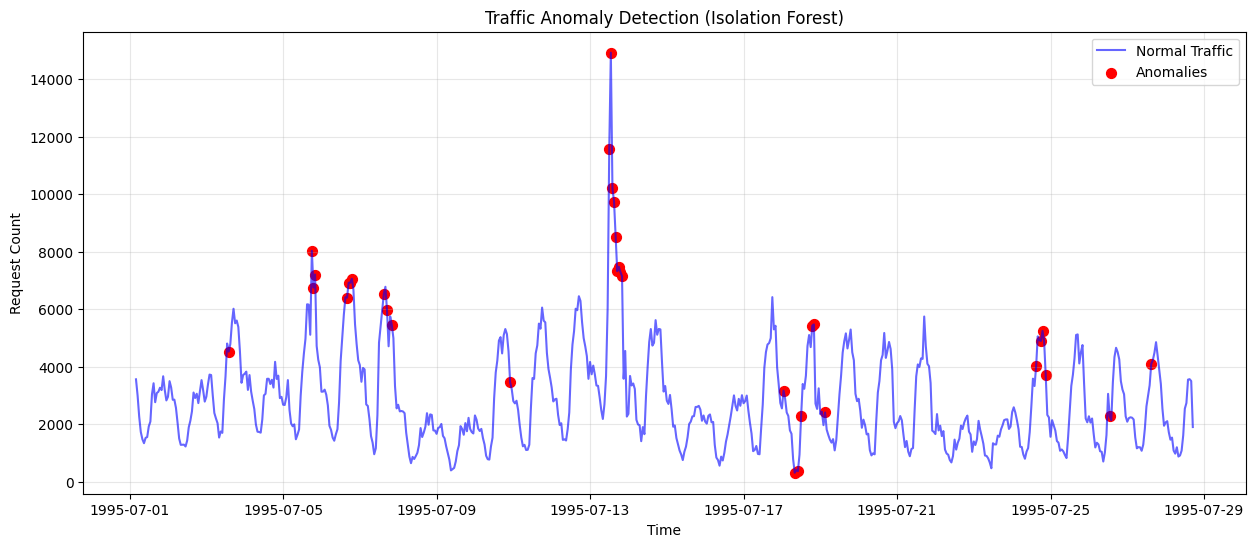

In [12]:
result_anomaly = run_anomaly_detection(raw_data)


--- Starting Gradient Boosting Training ---
Metrics logged to experiment_logs.csv


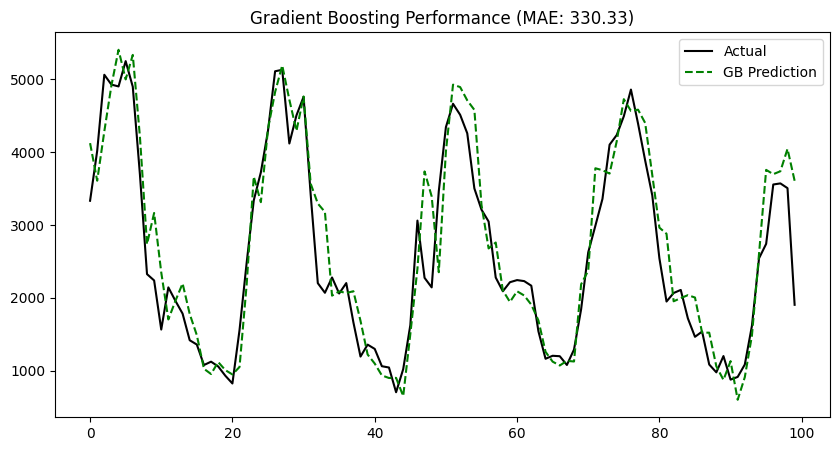

In [13]:
result_GBR = run_gradient_boosting(raw_data)

In [19]:
# Save Model
import joblib

joblib.dump(result_anomaly[0], "./model/anomaly_model.pkl")
joblib.dump(result_GBR[0], "./model/GBR_model.pkl")

['./model/GBR_model.pkl']